# Rigol DS1000B Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DS1000B_scopes

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/"

A list of Rigol scopes in the DS1000B family is:

In [2]:
print(DS1000B_scopes[:])

['B', '1000B', 'DS1000B', 'DS1074B', 'DS1104B', 'DS1204B']


## DS1204B-A

We will start with a `.wfm` file from a Rigol DS1204B scope which has saved all four channels.

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-A.bmp" width="50%">

### Now for the `.wfm` data

First a textual description.

In [3]:
# raw=true is needed because this is a binary file
wfm_url = repo + "wfm/DS1204B-A.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-A.wfm
        Channels     = [1, 2, 3, 4]

    Trigger:
        Mode     = edge
        Source   = CH1
        Derived Level     = 3.00  V

     Channel 1:
         Coupling =       DC
            Scale =     1.00  V/div
           Offset =    -2.52  V
            Probe =       1X
         Inverted =    False

        Time Base =    2.000 ms/div
           Offset =    0.000  s
            Delta =    8.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [       86,       86,       86  ...       163,      163]
           Times  = [-32.768 ms,-32.760 ms,-32.752 ms  ... 32.760 ms,32.768 ms]
           Volts  = [  3.04  V,  3.04  V,  3.04  V  ... -40.00 mV,-40.00 mV]

     Channel 2:
         Coupling =       DC
            Scale =     5.00

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-A.wfm?raw=true'


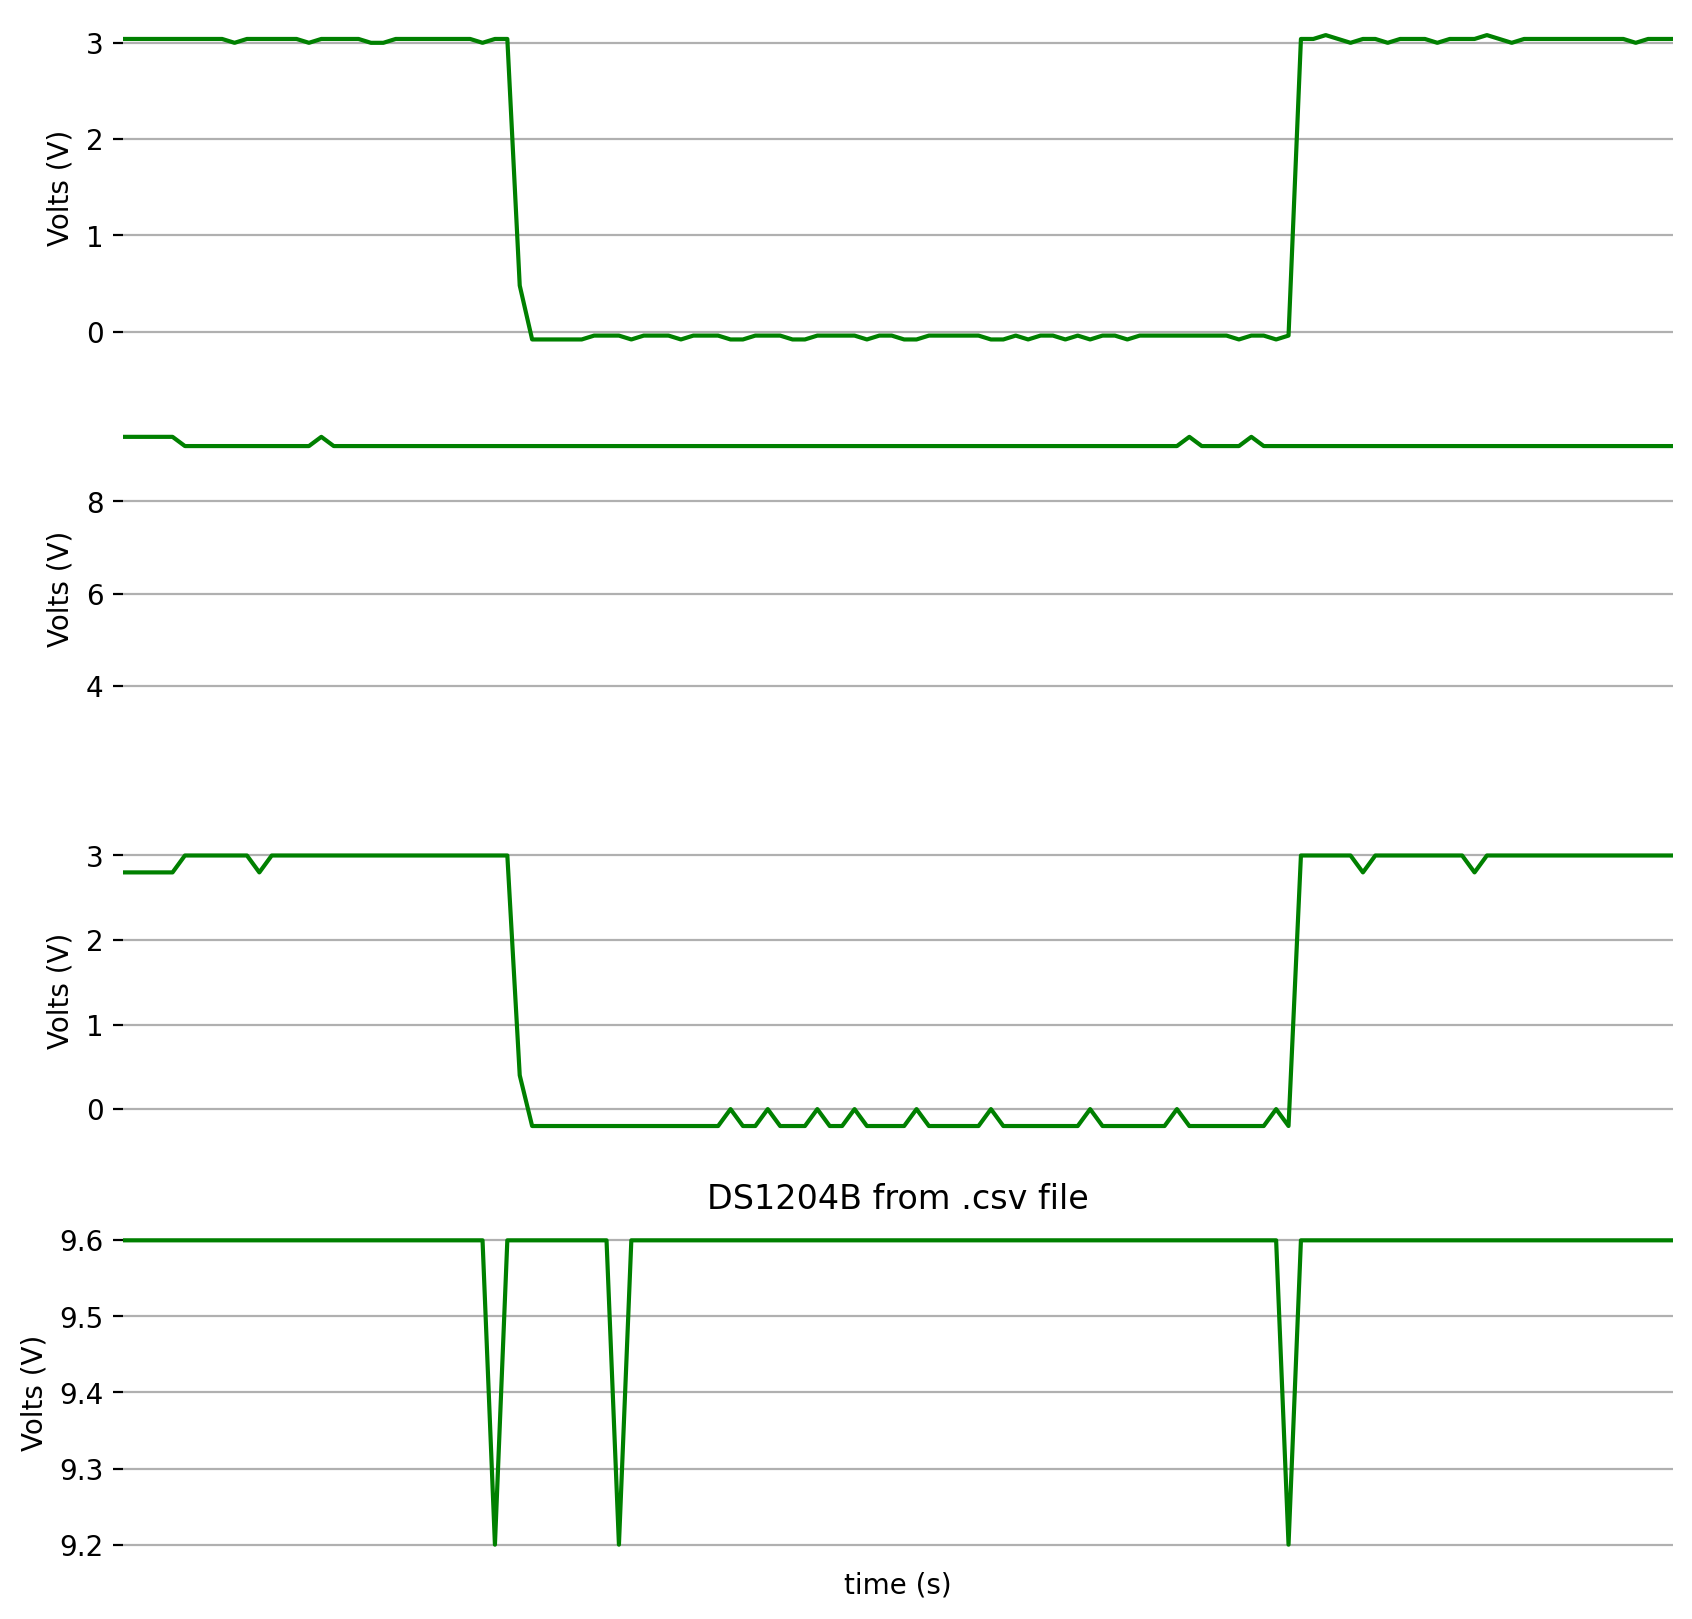

In [4]:
csv_file = repo + "wfm/DS1204B-A-original.csv"

csv_data = np.genfromtxt(csv_file, delimiter=",", skip_header=2, encoding="latin1").T

plt.subplots(4, 1, sharex=True, figsize=(10, 10), subplot_kw=dict(frameon=False, xlim=(-0.001, 0.001)))
plt.title("DS1204B from .csv file")

plt.subplot(411)
plt.plot(csv_data[0], csv_data[1], color="green")
plt.ylabel("Volts (V)")
plt.xlim(csv_data[0, 0], csv_data[0, 0] + 0.001)
plt.xticks([])
plt.grid(True)

plt.subplot(412)
plt.plot(csv_data[0], csv_data[2], color="green")
plt.ylabel("Volts (V)")
plt.xlim(csv_data[0, 0], csv_data[0, 0] + 0.001)
plt.xticks([])
plt.grid(True)

plt.subplot(413)
plt.plot(csv_data[0], csv_data[3], color="green")
plt.ylabel("Volts (V)")
plt.xlim(csv_data[0, 0], csv_data[0, 0] + 0.001)
plt.xticks([])
plt.grid(True)

plt.subplot(414)
plt.plot(csv_data[0], csv_data[4], color="green")
plt.ylabel("Volts (V)")
plt.xlim(csv_data[0, 0], csv_data[0, 0] + 0.001)
plt.xlabel("time (s)")
plt.grid(True)

# plt.xlim(center_time-0.6,center_time+0.6)

plt.show()

Plotting the .wfm results and the .csv values give us one single line.

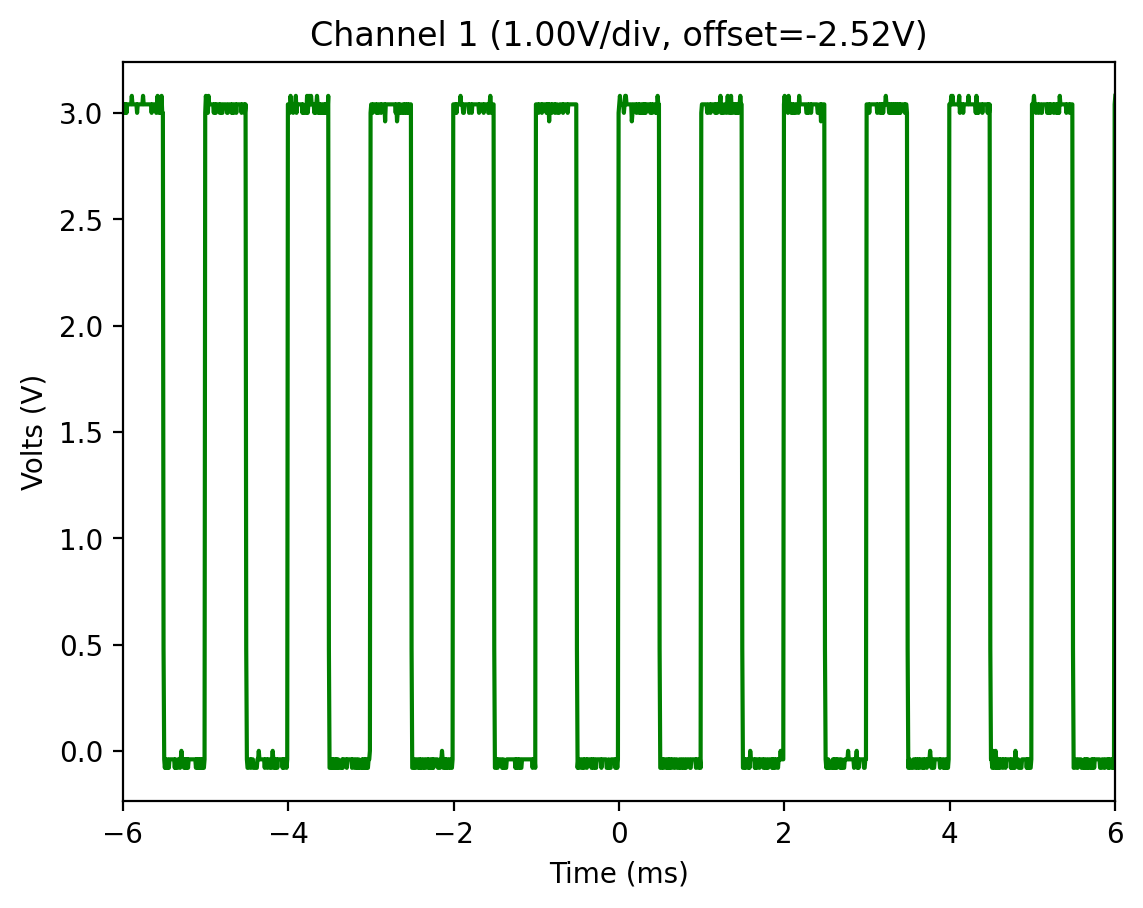

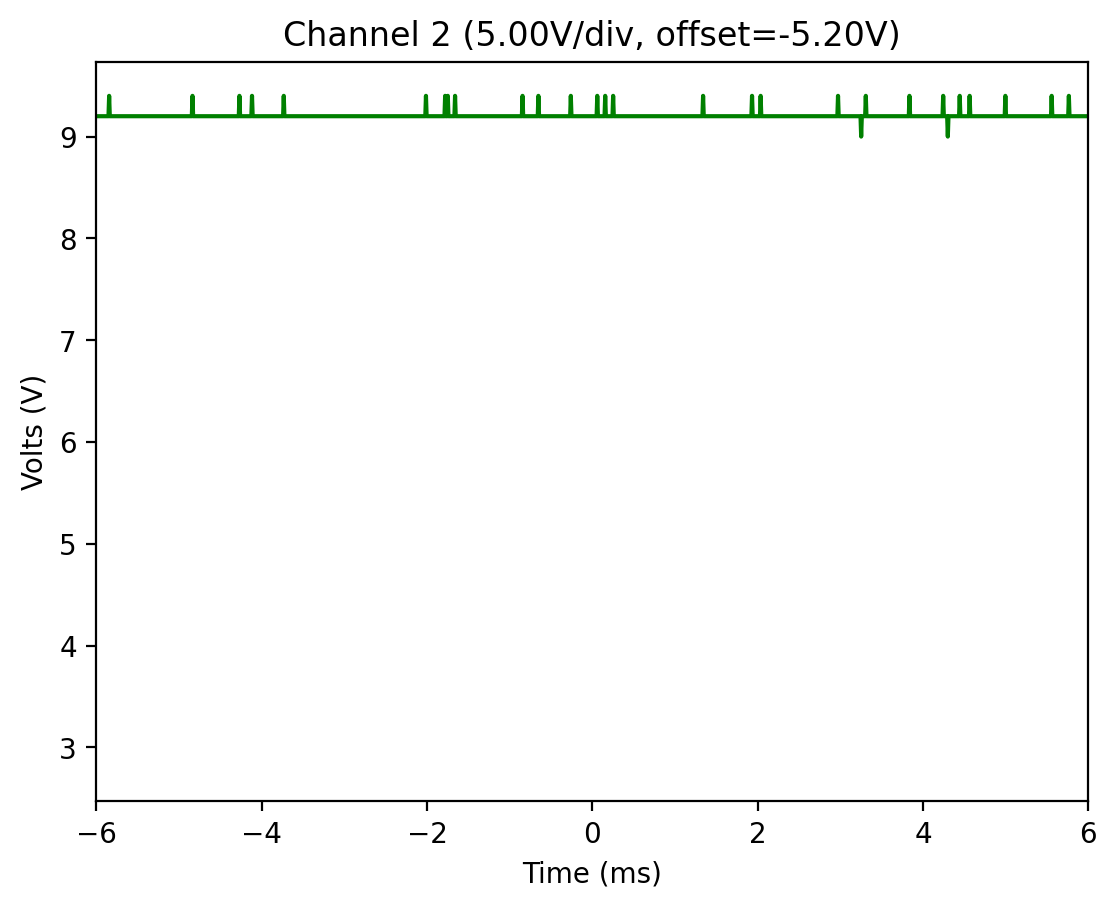

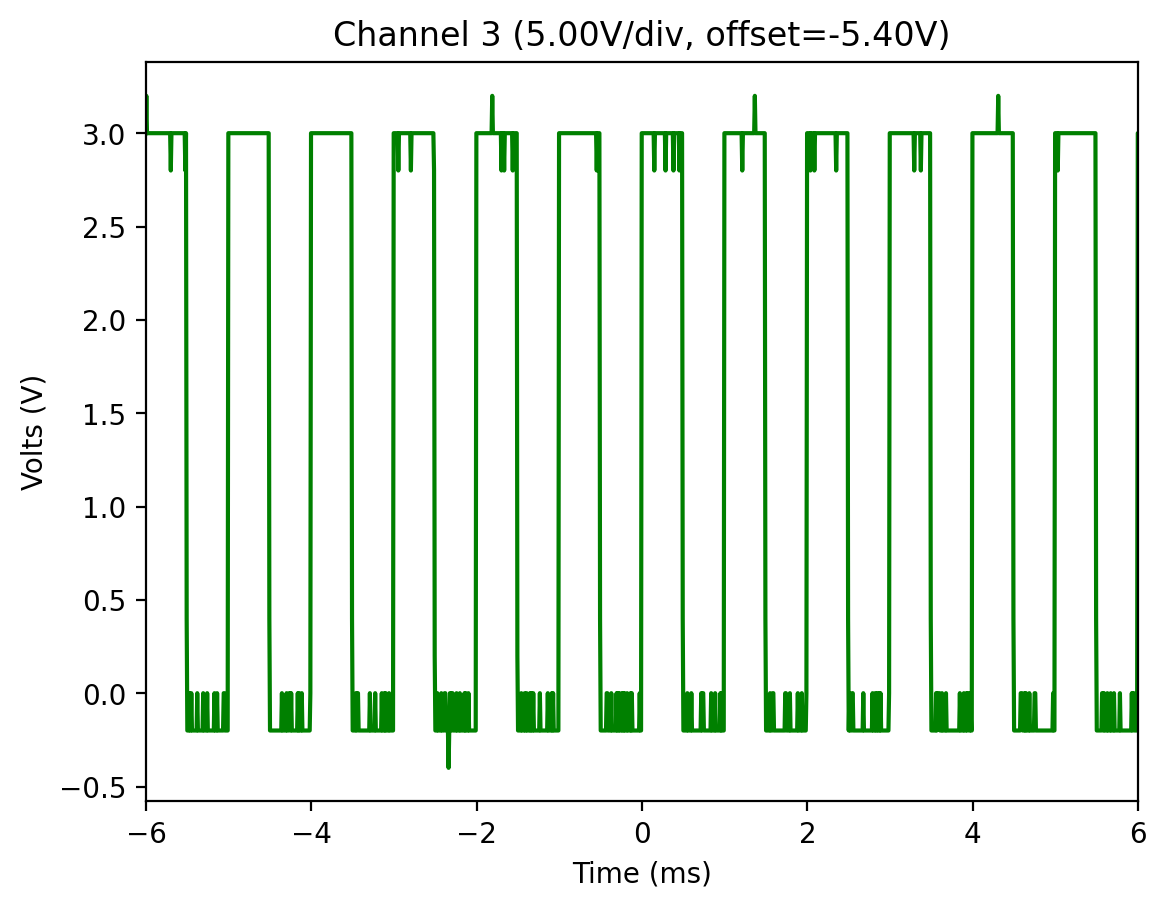

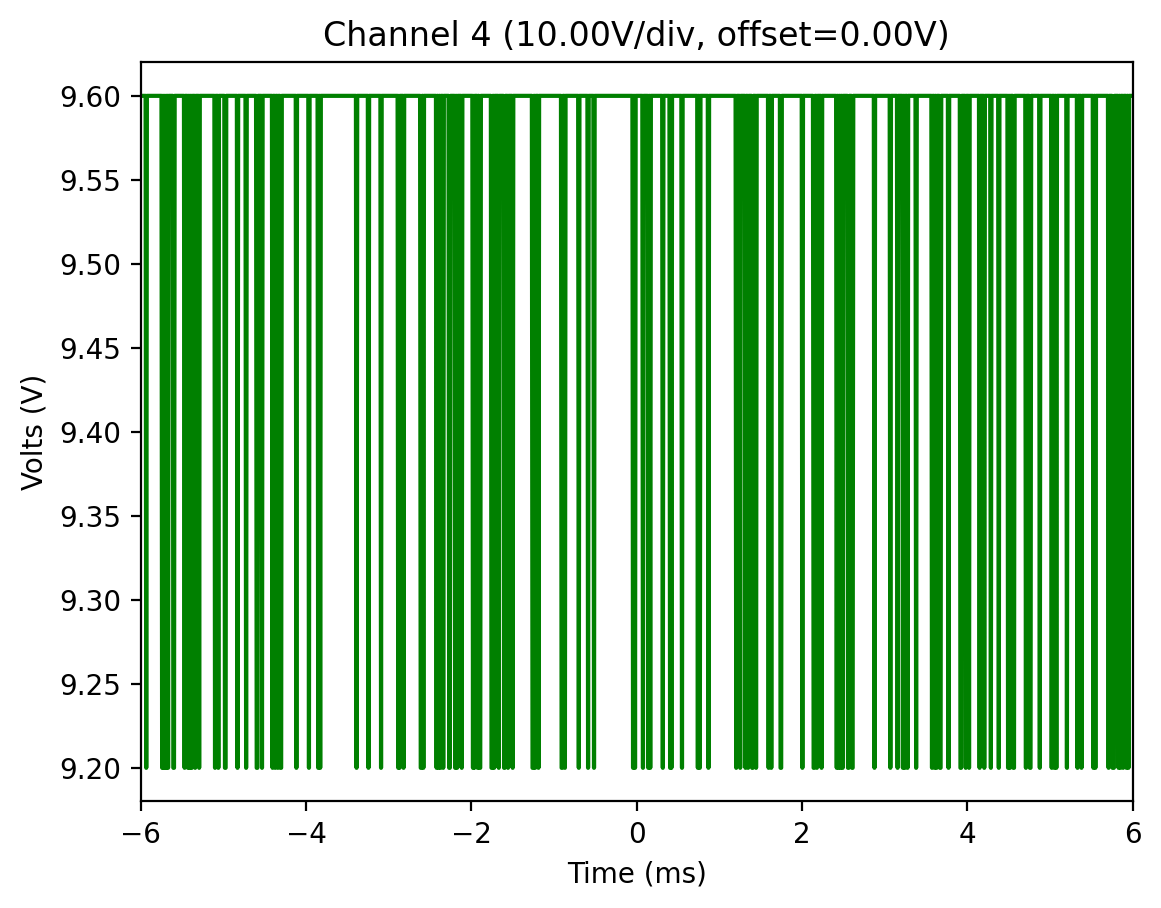

In [5]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

Differences are all essentially zero!

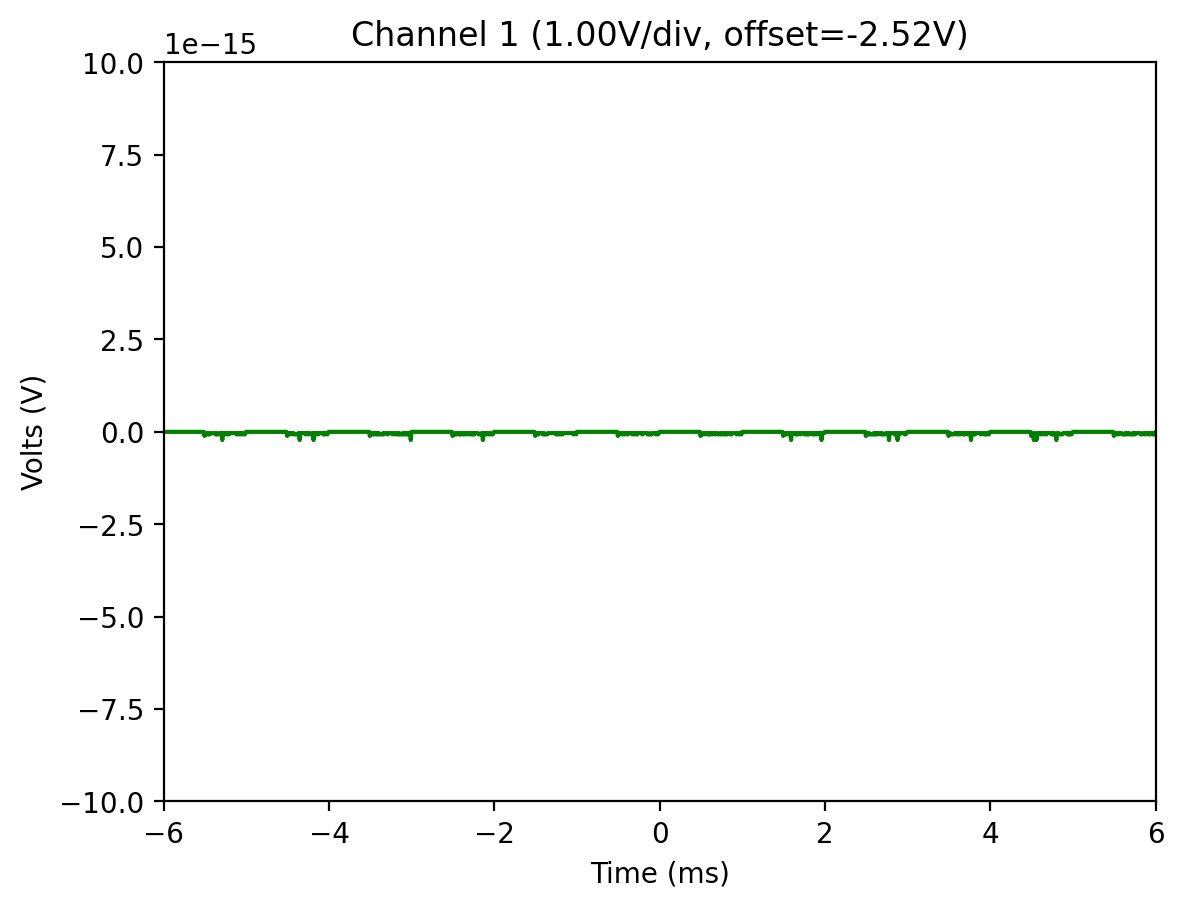

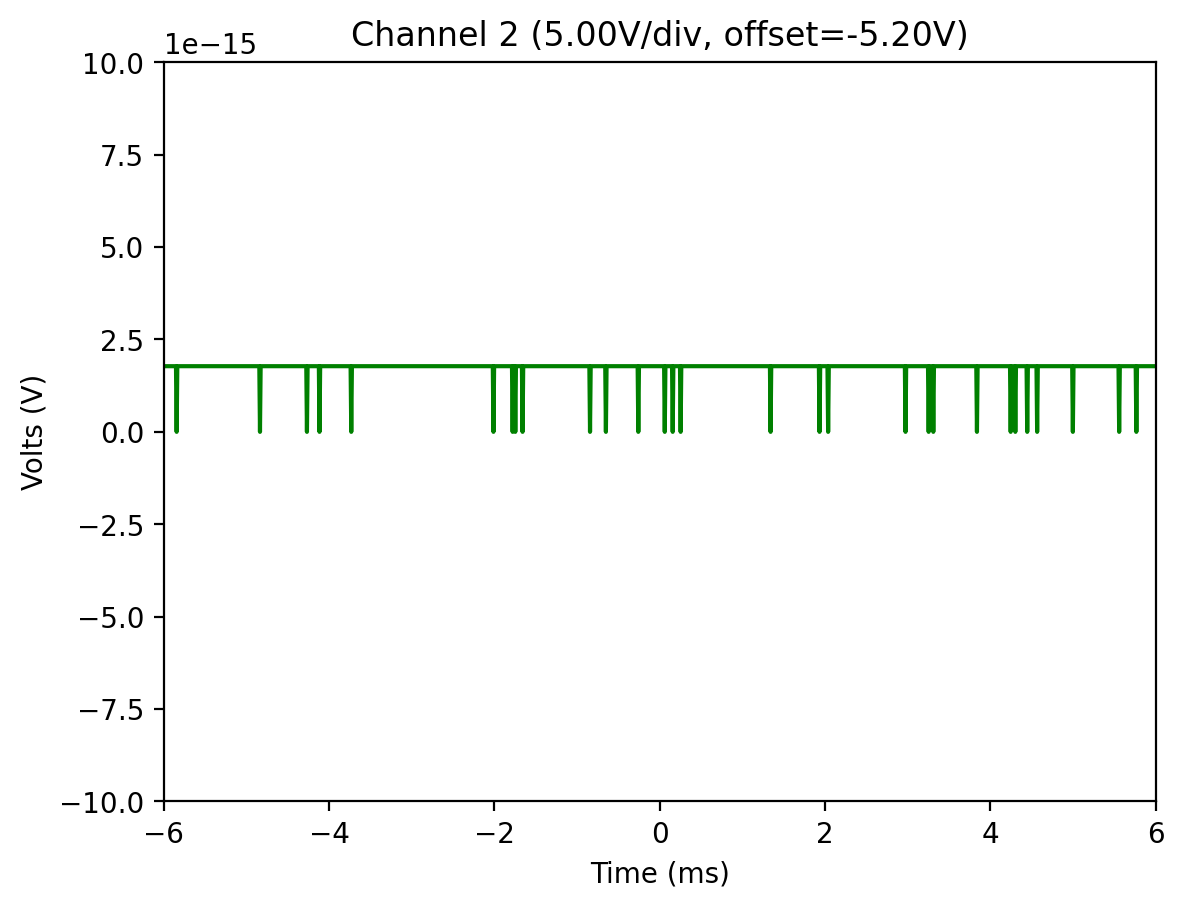

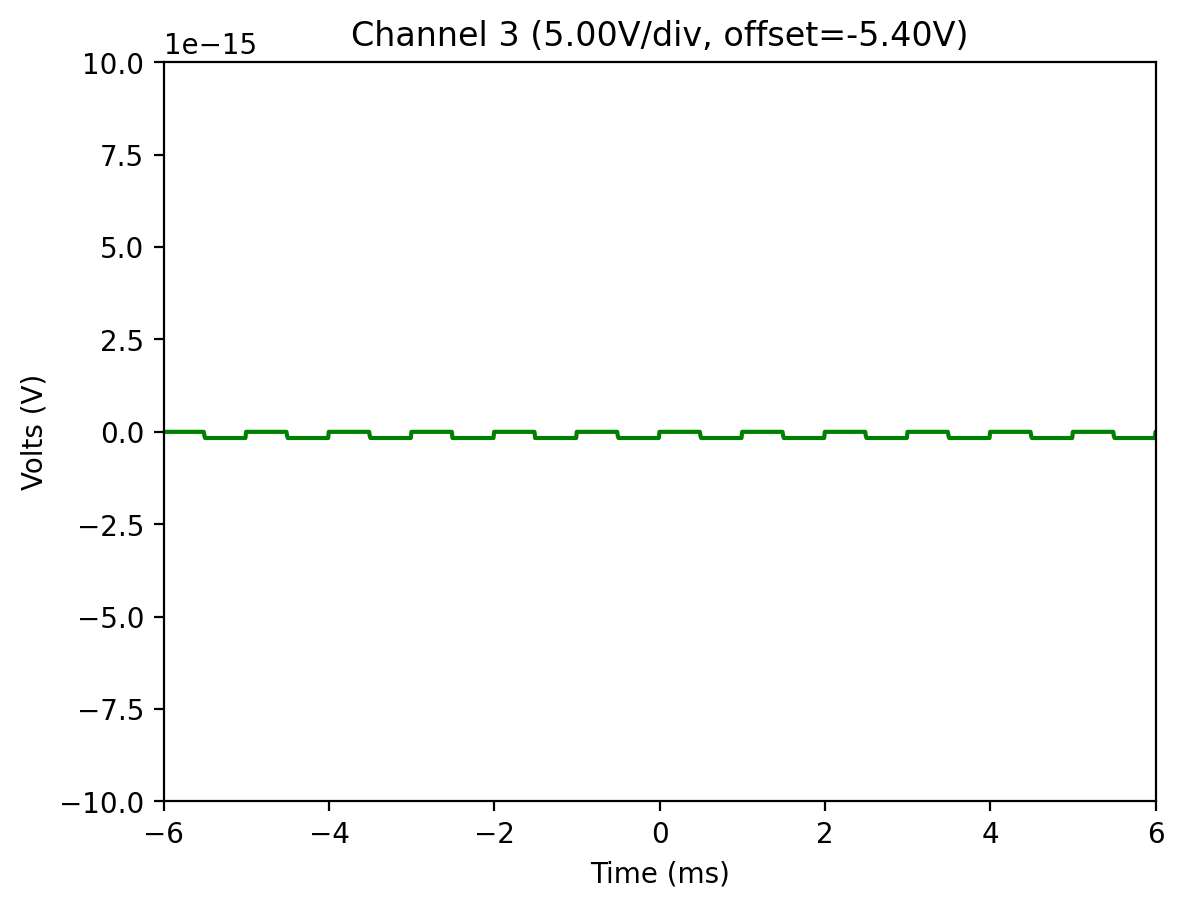

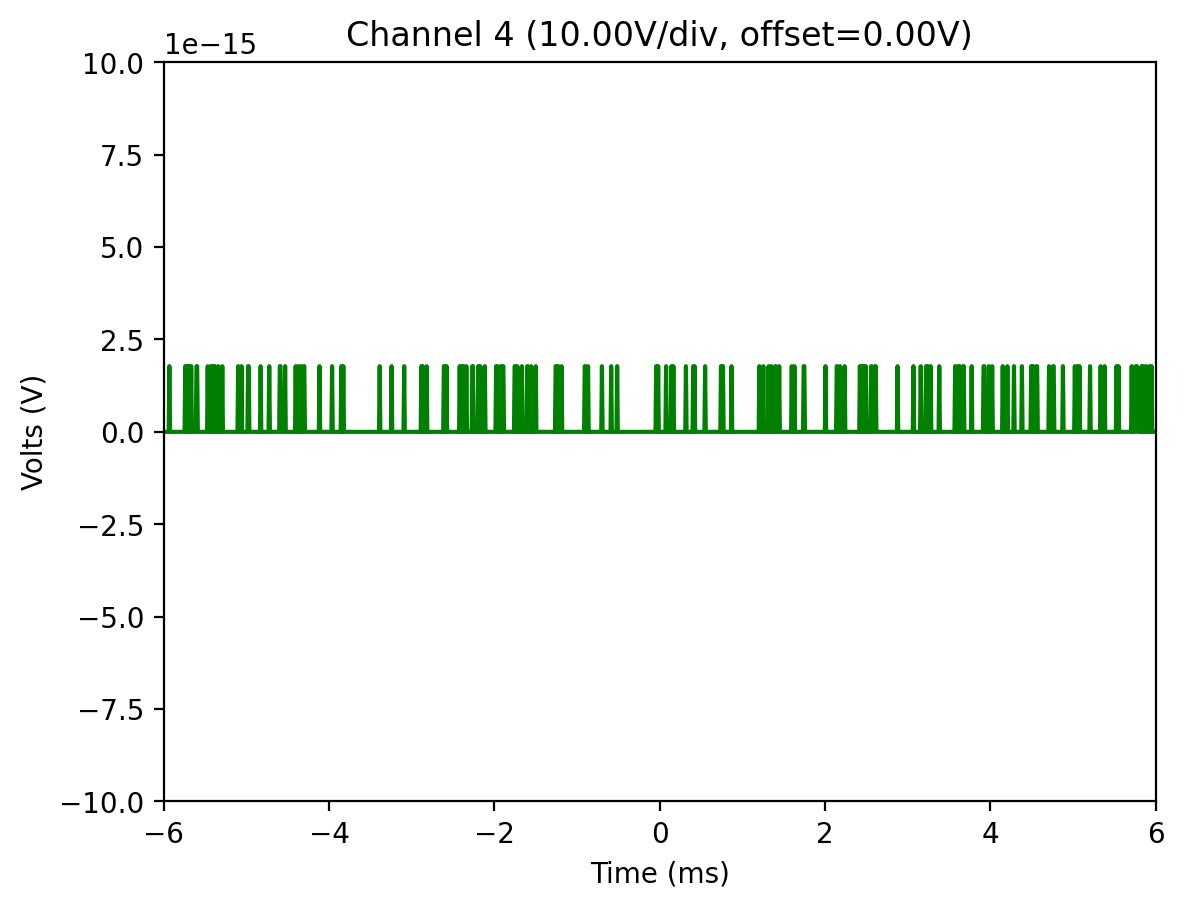

In [6]:
for i, ch in enumerate(w.channels):
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts - csv_data[i + 1], color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.ylim(-1e-14, 1e-14)
        plt.show()

## DS1204B-B

Rigol DS1204B waveform with just the first channel saved. 

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-B.png" width="50%">

In [7]:
# raw=true is needed because this is a binary file
wfm_url = repo + "wfm/DS1204B-B.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-B.wfm
        Channels     = [1]

    Trigger:
        Mode     = edge
        Source   = CH1
        Derived Level     = 15.20  V

     Channel 1:
         Coupling =       AC
            Scale =    10.00  V/div
           Offset =     0.00  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =    4.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [      138,      138,      138  ...        60,       60]
           Times  = [-16.384 ms,-16.380 ms,-16.376 ms  ... 16.380 ms,16.384 ms]
           Volts  = [-15.60  V,-15.60  V,-15.60  V  ...  15.60  V, 15.60  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-B.wfm?raw=true'


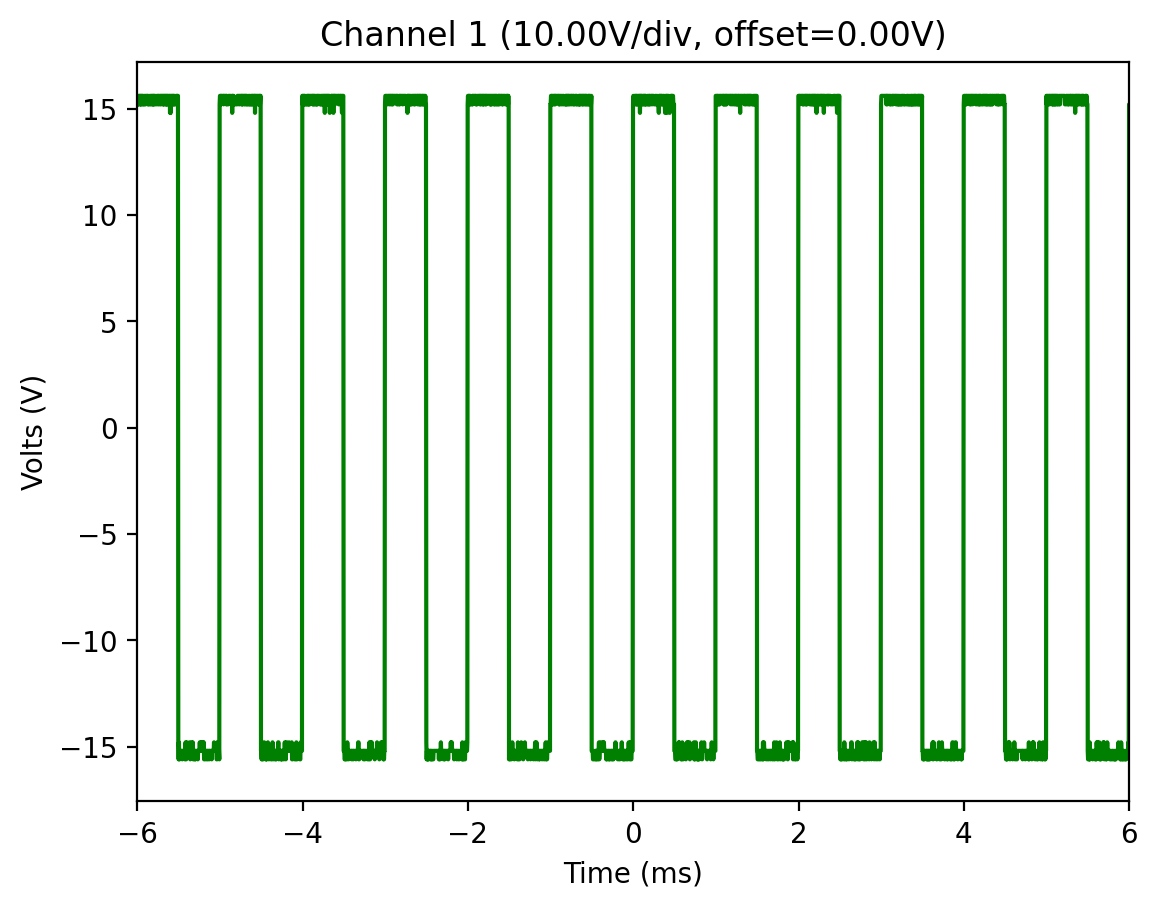

In [8]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

## DS1204B-C

Rigol DS1204B waveform with just the second channel saved. 

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-C.png" width="50%">

In [9]:
wfm_url = repo + "wfm/DS1204B-C.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-C.wfm
        Channels     = [2]

    Trigger:
        Mode     = edge
        Source   = CH1

     Channel 2:
         Coupling =       AC
            Scale =    10.00  V/div
           Offset =     0.00  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =    4.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [       61,       61,       61  ...        62,       62]
           Times  = [-16.384 ms,-16.380 ms,-16.376 ms  ... 16.380 ms,16.384 ms]
           Volts  = [ 15.20  V, 15.20  V, 15.20  V  ...  14.80  V, 14.80  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-C.wfm?raw=true'


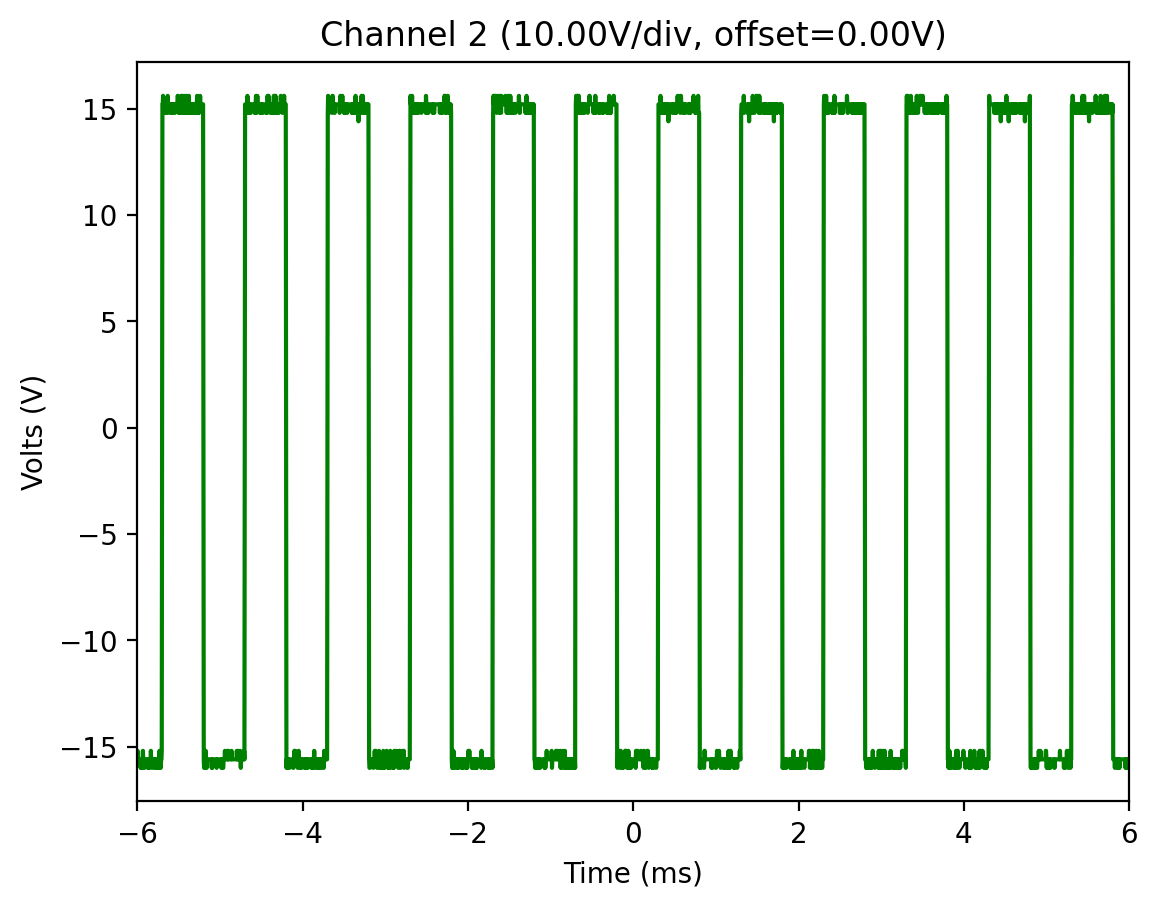

In [10]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

## DS1204B-D

Rigol DS1204B waveform with just the third channel saved. 

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-D.png" width="50%">

In [11]:
wfm_url = repo + "wfm/DS1204B-D.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-D.wfm
        Channels     = [3]

    Trigger:
        Mode     = edge
        Source   = CH1

     Channel 3:
         Coupling =       AC
            Scale =     5.00  V/div
           Offset =     0.00  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =    4.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [      175,      175,      175  ...       175,      175]
           Times  = [-16.384 ms,-16.380 ms,-16.376 ms  ... 16.380 ms,16.384 ms]
           Volts  = [-15.20  V,-15.20  V,-15.20  V  ... -15.20  V,-15.20  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-D.wfm?raw=true'


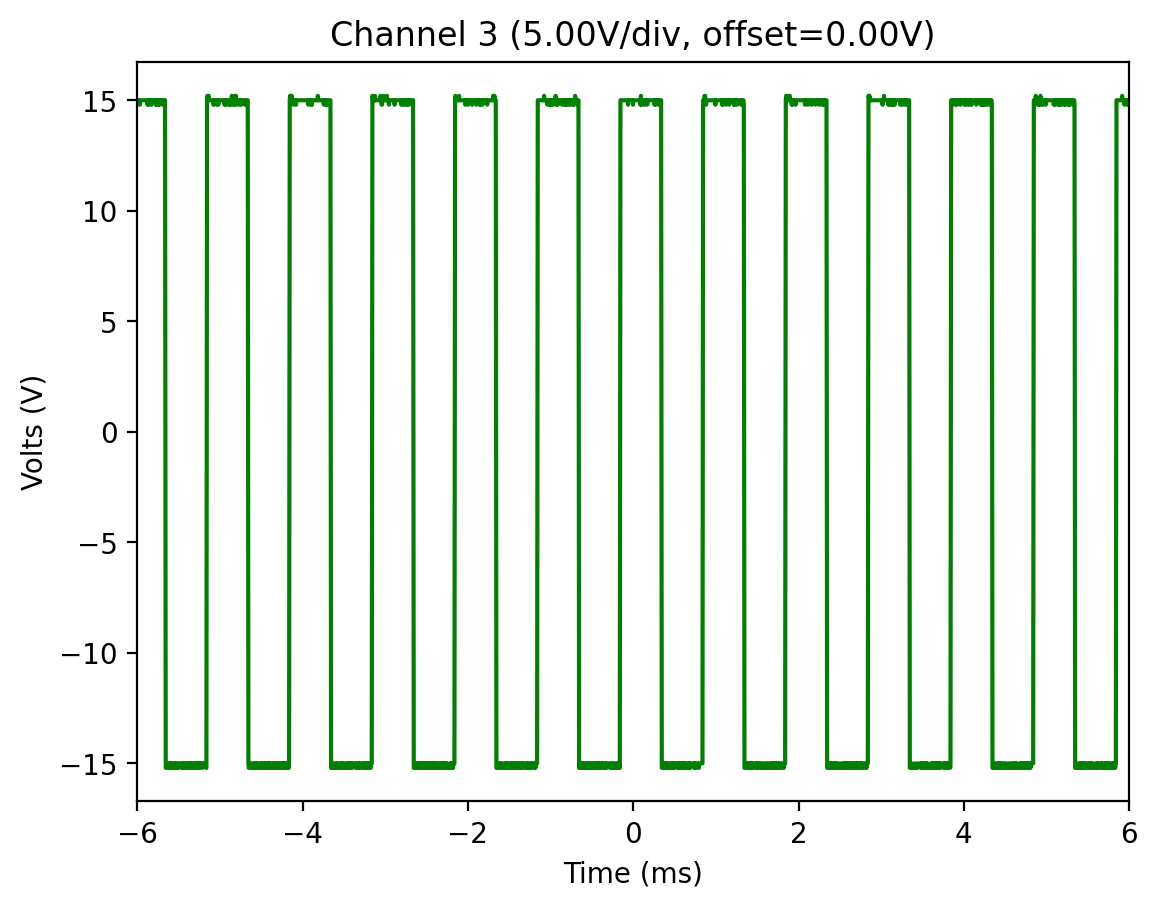

In [12]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

## DS1204B-E

Rigol DS1204B waveform with just the fourth channel saved. 

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-E.png" width="50%">

In [13]:
wfm_url = repo + "wfm/DS1204B-E.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-E.wfm
        Channels     = [4]

    Trigger:
        Mode     = edge
        Source   = CH1

     Channel 4:
         Coupling =       AC
            Scale =     5.00  V/div
           Offset =     0.00  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =    4.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [      174,      174,      174  ...        25,       25]
           Times  = [-16.384 ms,-16.380 ms,-16.376 ms  ... 16.380 ms,16.384 ms]
           Volts  = [-15.00  V,-15.00  V,-15.00  V  ...  14.80  V, 14.80  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-E.wfm?raw=true'


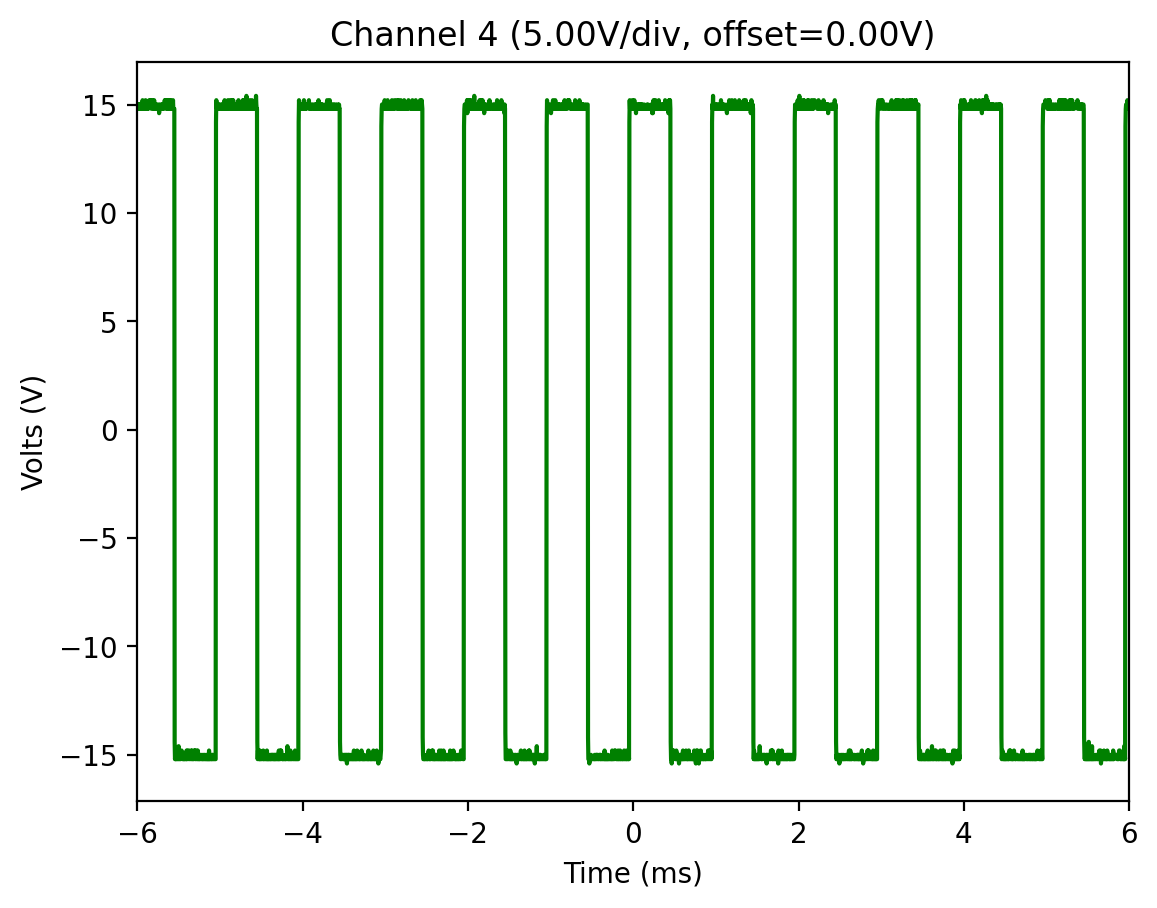

In [14]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

## DS1204B-F

This file has channels 2 & 4 saved.

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-F.png" width="50%">

In [15]:
wfm_url = repo + "wfm/DS1204B-F.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-F.wfm?raw=true'


    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-F.wfm
        Channels     = [2, 4]

    Trigger:
        Mode     = edge
        Source   = CH1

     Channel 2:
         Coupling =       AC
            Scale =    10.00  V/div
           Offset =   -20.40  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    0.000  s
            Delta =    4.000 µs/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [      113,      113,      113  ...       113,       98]
           Times  = [-16.384 ms,-16.380 ms,-16.376 ms  ... 16.380 ms,16.384 ms]
           Volts  = [ 14.80  V, 14.80  V, 14.80  V  ...  14.80  V, 20.80  V]

     Channel 4:
         Coupling =       AC
            Scale =    20.00  V/div
           Offset =    57.60  V
  

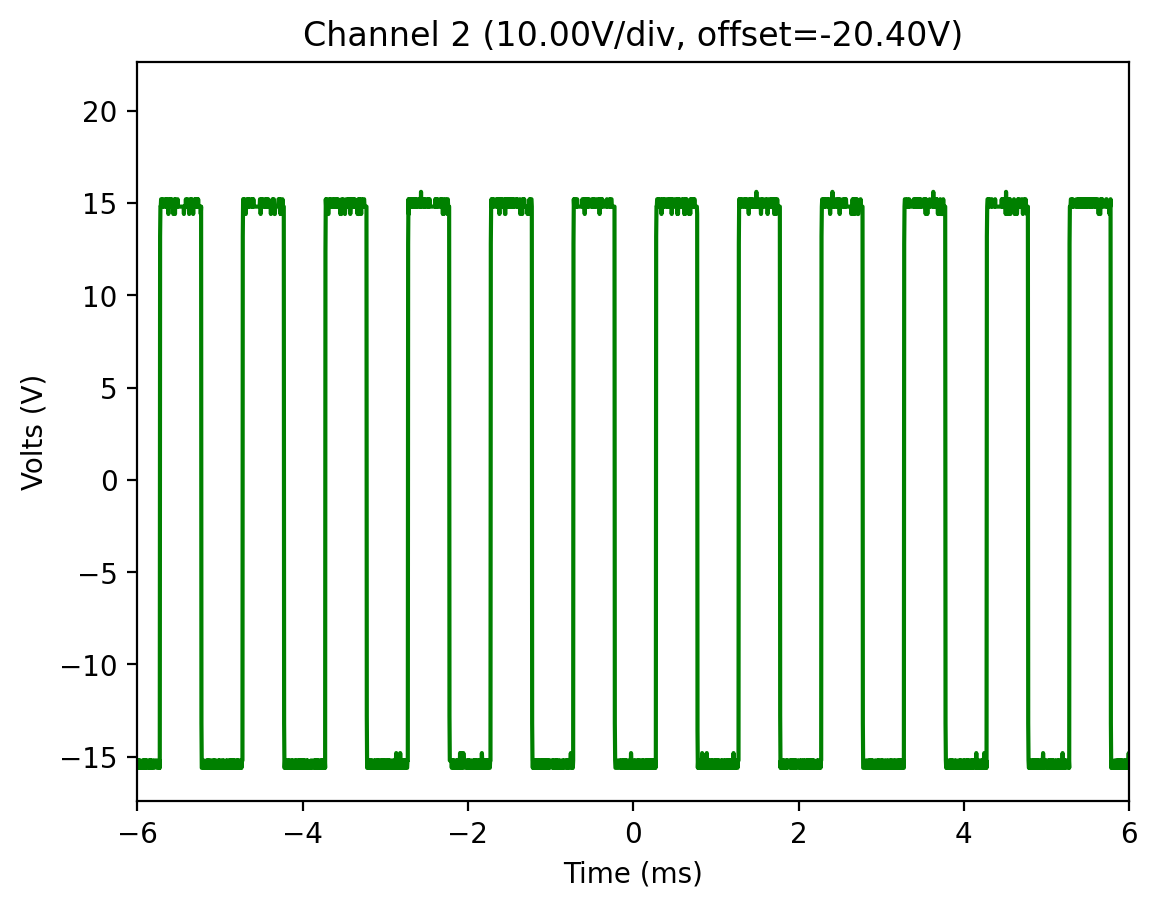

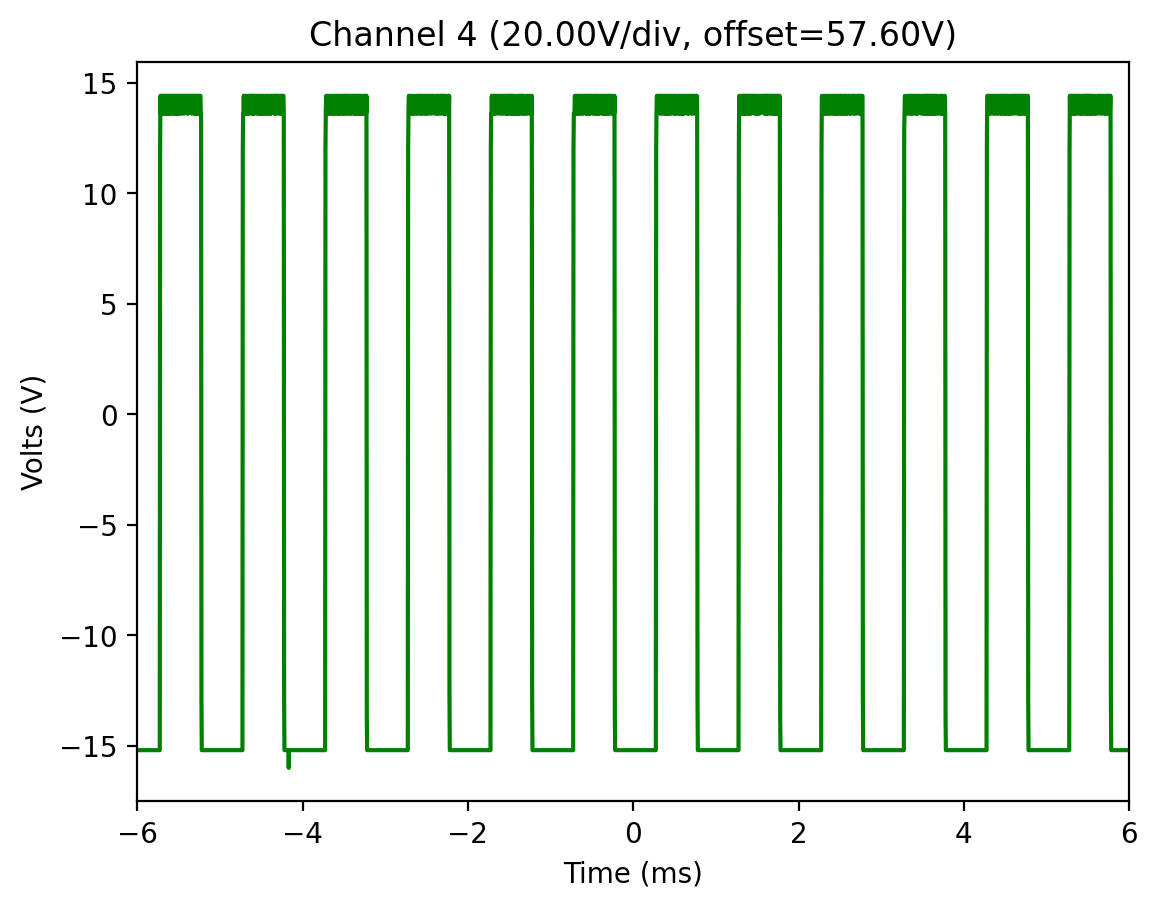

In [16]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1000, ch.volts, color="green")
        plt.title("Channel %d (%.2fV/div, offset=%.2fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (ms)")
        plt.ylabel("Volts (V)")
        plt.xlim(-6, 6)
        plt.show()

## DS1204B-G

It turns out that my initial guess on how data was stored was incorrect.  It seems to work fine for channels that are saved with 0x2000 bytes but fails with those with 0x4000.

Rigol DS1204B waveform with just the first channel saved with 0x4000 = 16384 points.

I made changes so this one and other files still parse correctly.

In [17]:
wfm_url = repo + "wfm/DS1204B-G.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000B")

description = w.describe()
print(description)

    General:
        File Model   = DS1000B
        User Model   = 1000B
        Parser Model = wfm1000b
        Firmware     = unknown
        Filename     = DS1204B-G.wfm
        Channels     = [1]

    Trigger:
        Mode     = edge
        Source   = CH1
        Derived Level     = 1.68 mV

     Channel 1:
         Coupling =       AC
            Scale =     2.00 mV/div
           Offset =    -2.00 mV
            Probe =       1X
         Inverted =    False

        Time Base =    5.000 ns/div
           Offset =    0.000  s
            Delta =  500.000 ps/point
           Points =    16384

         Count    = [        1,        2,        3  ...     16383,    16384]
           Raw    = [      125,      125,      125  ...       125,      125]
           Times  = [-4.096 µs,-4.095 µs,-4.095 µs  ...  4.095 µs, 4.096 µs]
           Volts  = [-80.00 µV,-80.00 µV,-80.00 µV  ... -80.00 µV,-80.00 µV]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1204B-G.wfm?raw=true'


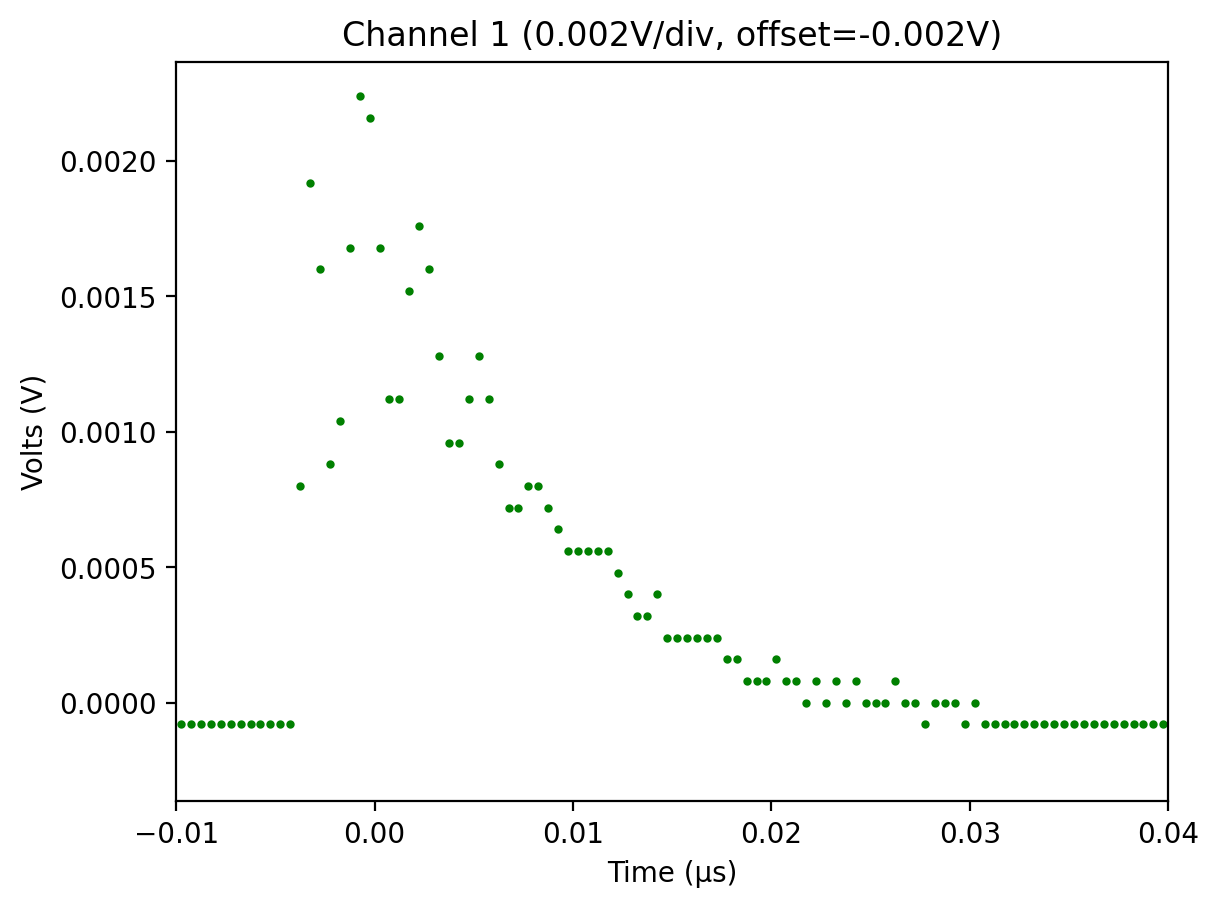

In [18]:
for ch in w.channels:
    if ch.enabled:
        plt.plot(ch.times * 1e6, ch.volts, "og", markersize=2)
        plt.title("Channel %d (%.3fV/div, offset=%.3fV)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset))
        plt.xlabel("Time (µs)")
        plt.ylabel("Volts (V)")
        plt.xlim(-0.01, 0.04)
        plt.show()

# 